# Second run using more complex tensor

We present here a simple example to show the basic functionalities. It uses a random input tensor, more complex examples can be explored in the other [notebook](SWoTTeD_module_example.ipynb).

## Exemple d'utilisation de trajectoryclusteringanalysis (multidimensionnel)

Cette section illustre un workflow complet du package `trajectoryclusteringanalysis` :
1. Initialiser TCA en mode multidimensionnel
2. Construire le tenseur $\mathbf{X}\in\{0,1\}^{K\times N\times T}$ (patient × événement × temps)
3. Apprendre la decomposition SWoTTeD
4. Extraire les intensites de phenotypes et clusteriser les patients

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
from pathlib import Path

# Locate the repository data folder regardless of current working directory
target_name = "multidimensional_data"
data_dir = None
for base in [Path.cwd(), *Path.cwd().parents]:
    candidate = base / "data"
    if (candidate / f"{target_name}.csv").exists():
        data_dir = candidate
        break

if data_dir is None:
    raise FileNotFoundError(
        f"Could not find a 'data' folder containing {target_name}.csv. "
        f"Current working directory: {Path.cwd()}"
    )

csv_path = data_dir / f"{target_name}.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(
        f"'{csv_path}' does not exist."
    )

print(f"Loaded data from: {csv_path}")

Loaded data from: c:\Users\imen.miloudi\Documents\stage\TrajectoryClusteringAnalysis\data\multidimensional_data.csv


In [2]:
df

,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3
...,...,...,...
20430,1336,Chimiothérapie IV,2
20431,1336,Chimiothérapie IV,2
20432,1336,Chimiothérapie IV,3
20433,1336,Chimiothérapie IV,3


In [3]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
timed_event_structure

,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0
...,...,...,...
20430,1336,2,0
20431,1336,2,0
20432,1336,3,0
20433,1336,3,0


In [4]:
nunique = timed_event_structure['ID_PATIENT'].nunique()
print(f"Number of unique patients: {nunique}")

Number of unique patients: 1336


In [5]:
# Get the set of all unique Event values
unique_events = timed_event_structure['Event'].unique()
all_events = set(unique_events)

# Find patients who have all occurrences of Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[   8   23   45   65   66  134  157  173  176  178  188  194  220  228
  242  275  312  343  361  390  428  466  469  472  478  537  544  546
  575  613  665  673  688  759  775  790  792  831  845  867  895  937
  943  969  984 1081 1126 1286 1293 1333]


## Guide rapide: pipeline TCA multidimensionnel

Dans cette partie, on suit un enchainement simple et reproductible:
1. Configurer l'import du package (local)
2. Initialiser `TCA` en mode multidimensionnel
3. Construire le tenseur
4. Entrainer SWoTTeD
5. Clusteriser les intensites de phenotypes

In [6]:
from pathlib import Path
import sys
import importlib
import inspect

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import trajectoryclusteringanalysis.multidimensional.analysis as md_analysis
import trajectoryclusteringanalysis.multidimensional as md_pkg
import trajectoryclusteringanalysis.tca as tca_module
import trajectoryclusteringanalysis as tca_pkg

# Force reload to avoid stale class signature in notebook kernel
importlib.reload(md_analysis)
importlib.reload(md_pkg)
importlib.reload(tca_module)
importlib.reload(tca_pkg)

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")
print("Active fit_swotted_decomposition signature:")
print(inspect.signature(md_analysis.MultidimensionalAnalyzer.fit_swotted_decomposition))

Using local package from: c:\Users\imen.miloudi\Documents\stage\TrajectoryClusteringAnalysis\src


In [7]:
from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

### 2) Initialiser TCA (mode multidimensionnel)

`TCA` encapsule la préparation des données, la décomposition SWoTTeD et les outils de clustering/visualisation.

In [8]:
# Créer une instance de TCA pour l'analyse multidimensionnelle
tca = TCA(data=timed_event_structure,
              index_col='ID_PATIENT',
              time_col='Time', 
              event_col='Event',
              mode='multidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


### 3) Construire le tenseur multidimensionnel

Transformation du format long (`ID_PATIENT`, `Time`, `Event`) vers un tenseur binaire `(K, N, T)`.

In [9]:
tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

Tensor shape: torch.Size([1336, 4, 24])


### 4) Parametrer et entrainer SWoTTeD

Commence avec peu d'epochs pour une demo rapide, puis augmente pour ameliorer la qualite.

In [10]:
# Hyperparametres de la demo
rank = 3
time_window_length = 3
reg_term_ns = 0.9
reg_term_s = 0.1
metric = 'Bernoulli'
learning_rate = 1e-2


Patient utilise pour la visualisation: 8


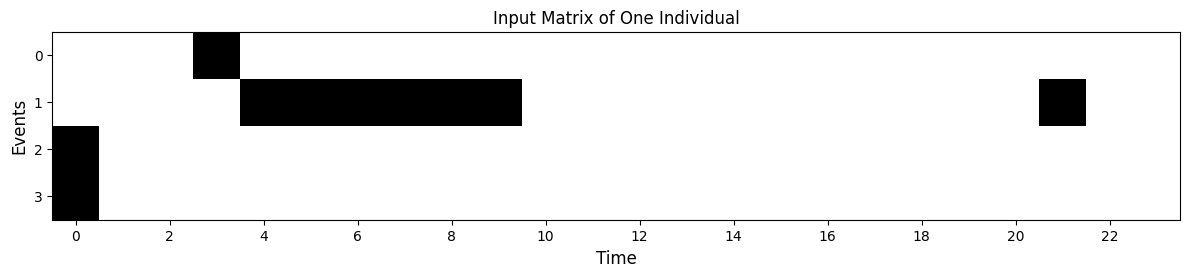

In [ ]:
patient_index = int(patients_with_all_events[0])
print(f"Patient utilise pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=tca.label_to_encoded)

### Affichage des metriques

- En mode rapide (fit_metric_every_n_epochs=0), on n'affiche pas la FIT metric pendant l'entrainement pour ne pas ralentir.
- Tu peux activer la FIT metric ponctuellement avec fit_metric_every_n_epochs=10 (ou 1 pour chaque epoch).
- La success rate est affichee dans get_decomposition_results apres l'entrainement.

In [12]:
n_epochs = 200
# Sous Windows, une petite valeur comme 1 ou 2 fonctionne bien avec un collate_fn sérialisable.
tca.analyzer.fit_swotted_decomposition(tensor,
                                       rank,
                                       time_window_length,
                                       reg_term_ns, 
                                       reg_term_s, 
                                       metric, 
                                       learning_rate, 
                                       n_epochs,
                                       fit_metric_every_n_epochs=5,
                                       fit_metric_eval_max_patients=64,  # FIT approx pendant training
                                       num_workers=0,
                                       early_stopping_patience=10,
                                       early_stopping_min_delta=1e-4,
                                       early_stopping_monitor='fit_metric')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 36     | n/a   | n/a  
---------------------------------------------------------------
36        Trainable params
0         Non-trainable params
36        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
0         Total Flops



 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 : - train_loss_Ph: 15.309183 - train_loss_W: 51.304573 - train_loss_total: 66.613756 - duration: 4.70s - FIT metric: 0.1367
    early stopping: Metric fit_metric initialized at 0.137.
    checkpoint: New best FIT metric = 0.1367 at epoch 1.
Epoch 2/200 : - train_loss_Ph: 14.724079 - train_loss_W: 49.461155 - train_loss_total: 64.185234 - duration: 4.37s
Epoch 3/200 : - train_loss_Ph: 14.829329 - train_loss_W: 48.349419 - train_loss_total: 63.178747 - duration: 3.91s
Epoch 4/200 : - train_loss_Ph: 20.126957 - train_loss_W: 52.331108 - train_loss_total: 72.458065 - duration: 3.95s
Epoch 5/200 : - train_loss_Ph: 14.790115 - train_loss_W: 45.968987 - train_loss_total: 60.759102 - duration: 3.95s - FIT metric: 0.1214
Epoch 6/200 : - train_loss_Ph: 23.586109 - train_loss_W: 53.381393 - train_loss_total: 76.967503 - duration: 3.91s
Epoch 7/200 : - train_loss_Ph: 16.932957 - train_loss_W: 45.812737 - train_loss_total: 62.745693 - duration: 4.26s
Epoch 8/200 : - train_loss_Ph: 14.91

In [12]:
import inspect
from swotted.utils import success_rate
print(inspect.getsource(success_rate))

def success_rate(base, result):
    """
    Parameters
    -----------
    base: torch.Tensor
        phenotypes, pathways or patients matrices
    result: torch.Tensor
        tensor with the same shape as base
    """
    dis = 0
    max = 0
    for i in range(len(base)):
        dis += torch.norm((base[i] - result[i]), p="fro").item()
        max += torch.norm(base[i], p="fro").item()

    try:
        return 1 - dis / max
    except ZeroDivisionError:
        return 0



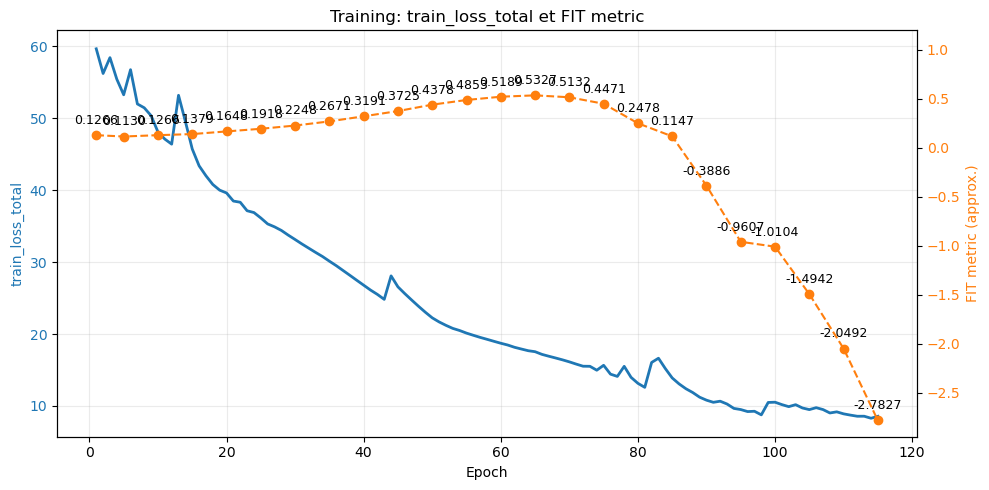

In [173]:
import matplotlib.pyplot as plt

history = getattr(tca.analyzer, 'training_history', None)
if not history or len(history.get('epoch', [])) == 0:
    raise ValueError("Aucun historique d'entrainement disponible. Execute d'abord la cellule d'entrainement.")

epochs = history['epoch']
train_loss_total = history['train_loss_total']
fit_epochs = history['fit_metric_points_epoch']
fit_values = history['fit_metric_points_value']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(epochs, train_loss_total, color='tab:blue', linewidth=2, label='train_loss_total')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('train_loss_total', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
if len(fit_epochs) > 0:
    ax2.plot(fit_epochs, fit_values, color='tab:orange', marker='o', linestyle='--', label='FIT metric')
    for x, y in zip(fit_epochs, fit_values):
        ax2.annotate(f"{y:.4f}", (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

    # Add headroom so FIT labels are easier to read near the top edge.
    fit_min = min(fit_values)
    fit_max = max(fit_values)
    fit_span = max(fit_max - fit_min, 1e-6)
    ax2.set_ylim(bottom=fit_min - 0.05 * fit_span, top=fit_max + 0.20 * fit_span)

ax2.set_ylabel('FIT metric (approx.)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.title('Training: train_loss_total et FIT metric')
plt.tight_layout()
plt.show()

# # afficher la valeur du FIT au moment du best fit_metric
# if history.get('best_fit_metric') is not None:
#     print(f"Best FIT metric during training: {history['best_fit_metric']:.4f}")

In [187]:
n_epochs = 200
# Sous Windows, une petite valeur comme 1 ou 2 fonctionne bien avec un collate_fn sérialisable.
tca.analyzer.fit_swotted_decomposition(tensor,
                                       rank,
                                       time_window_length,
                                       reg_term_ns, 
                                       reg_term_s, 
                                       metric, 
                                       learning_rate, 
                                       n_epochs,
                                       fit_metric_every_n_epochs=5,
                                       fit_metric_eval_max_patients=64,  # FIT approx pendant training
                                       restore_best_fit_checkpoint=False,
                                       num_workers=0,
                                       early_stopping_patience=None,
                                       early_stopping_min_delta=1e-4,
                                       early_stopping_monitor='fit_metric')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 36     | n/a   | n/a  
---------------------------------------------------------------
36        Trainable params
0         Non-trainable params
36        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
0         Total Flops
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\sit

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/200 : - train_loss_Ph: 14.548601 - train_loss_W: 46.392403 - train_loss_total: 60.941004 - duration: 1.45s - FIT metric: 0.1359
    checkpoint: New best FIT metric = 0.1359 at epoch 1.
Epoch 2/200 : - train_loss_Ph: 15.270493 - train_loss_W: 45.916756 - train_loss_total: 61.187248 - duration: 1.48s
Epoch 3/200 : - train_loss_Ph: 16.580212 - train_loss_W: 46.061241 - train_loss_total: 62.641453 - duration: 1.48s
Epoch 4/200 : - train_loss_Ph: 16.613632 - train_loss_W: 44.946594 - train_loss_total: 61.560226 - duration: 1.42s
Epoch 5/200 : - train_loss_Ph: 16.445621 - train_loss_W: 43.669323 - train_loss_total: 60.114944 - duration: 1.41s - FIT metric: 0.1129
Epoch 6/200 : - train_loss_Ph: 16.258265 - train_loss_W: 42.394890 - train_loss_total: 58.653154 - duration: 1.45s
Epoch 7/200 : - train_loss_Ph: 16.088215 - train_loss_W: 41.158272 - train_loss_total: 57.246487 - duration: 1.46s
Epoch 8/200 : - train_loss_Ph: 15.924178 - train_loss_W: 39.954582 - train_loss_total: 55.878760

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200 : - train_loss_Ph: 6.672451 - train_loss_W: 0.578947 - train_loss_total: 7.251398 - duration: 2.21s - FIT metric: -9.4927
 -> Training complete.

 -> Computing FIT metric on full tensor ...
 -> Global FIT metric computed from last epoch model: -9.6410 (time: 138.63s)

 -> Computing final decomposition on full tensor ...
 -> Decomposition finished (time: 139.05s)


Decomposed into 1336 pathways with rank 3 and time window length 3
FIT metric for the entire dataset: 0.2082
success_rate :0.1521280690122241


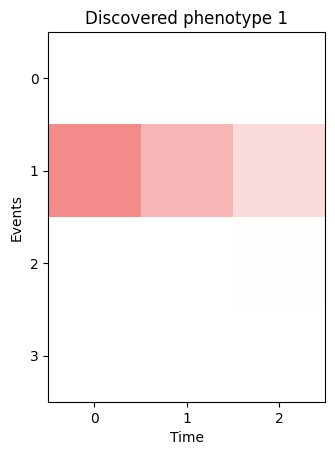

In [13]:
import matplotlib.pyplot as plt

history = getattr(tca.analyzer, 'training_history', None)
if not history or len(history.get('epoch', [])) == 0:
    raise ValueError("Aucun historique d'entrainement disponible. Execute d'abord la cellule d'entrainement.")

epochs = history['epoch']
train_loss_total = history['train_loss_total']
fit_epochs = history['fit_metric_points_epoch']
fit_values = history['fit_metric_points_value']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(epochs, train_loss_total, color='tab:blue', linewidth=2, label='train_loss_total')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('train_loss_total', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
if len(fit_epochs) > 0:
    ax2.plot(fit_epochs, fit_values, color='tab:orange', marker='o', linestyle='--', label='FIT metric')
    for x, y in zip(fit_epochs, fit_values):
        ax2.annotate(f"{y:.4f}", (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

    # Add headroom so FIT labels are easier to read near the top edge.
    fit_min = min(fit_values)
    fit_max = max(fit_values)
    fit_span = max(fit_max - fit_min, 1e-6)
    ax2.set_ylim(bottom=fit_min - 0.05 * fit_span, top=fit_max + 0.20 * fit_span)

ax2.set_ylabel('FIT metric (approx.)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
plt.title('Training: train_loss_total et FIT metric')
plt.tight_layout()
plt.show()

# # afficher la valeur du FIT au moment du best fit_metric
# if history.get('best_fit_metric') is not None:
#     print(f"Best FIT metric during training: {history['best_fit_metric']:.4f}")

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Total combinaisons: 48 | Executees: 12

[1/12] rank=4, twl=3, reg_ns=0.3, reg_s=0.3, lr=0.005
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | model        | SlidingWindow | 0      | train
  | other params | n/a           | 48     | n/a  
-------------------------------------------------------
48        Trainable params
0         Non-trainable params
48        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the va

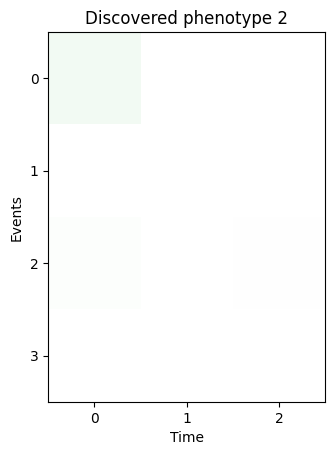

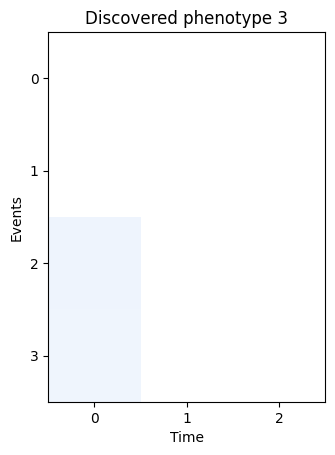

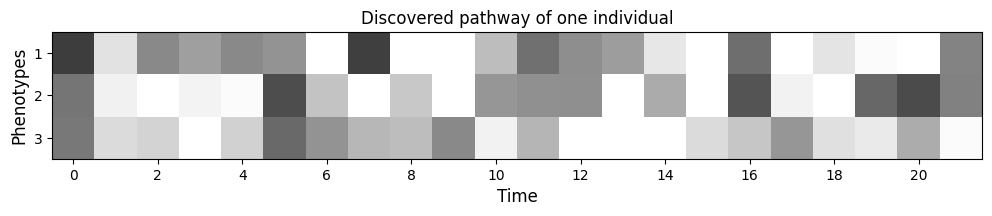

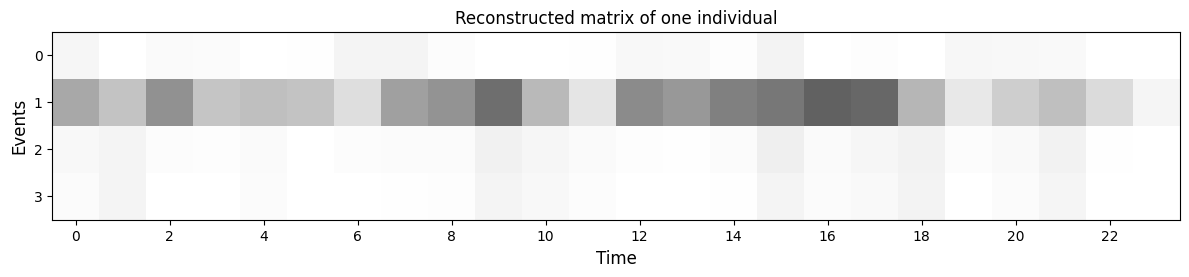

In [85]:
tca.analyzer.get_decomposition_results(labels=tca.label_to_encoded, id=patient_index)

In [14]:
from sklearn.preprocessing import StandardScaler

ph_intensity = tca.analyzer.to_phenotype_intensity(scaler=StandardScaler())
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,-0.143667,-0.070315,0.230218,1
1,0.228741,-0.397516,0.957191,2
2,1.869138,0.431901,0.275757,3
3,0.997543,1.208708,0.611792,4
4,0.220715,-0.027032,-1.002149,5


### 5) Extraire les intensites et clusteriser

On resume chaque patient par ses intensites de phenotypes, puis on applique un clustering hierarchique.

INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.01 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:228: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


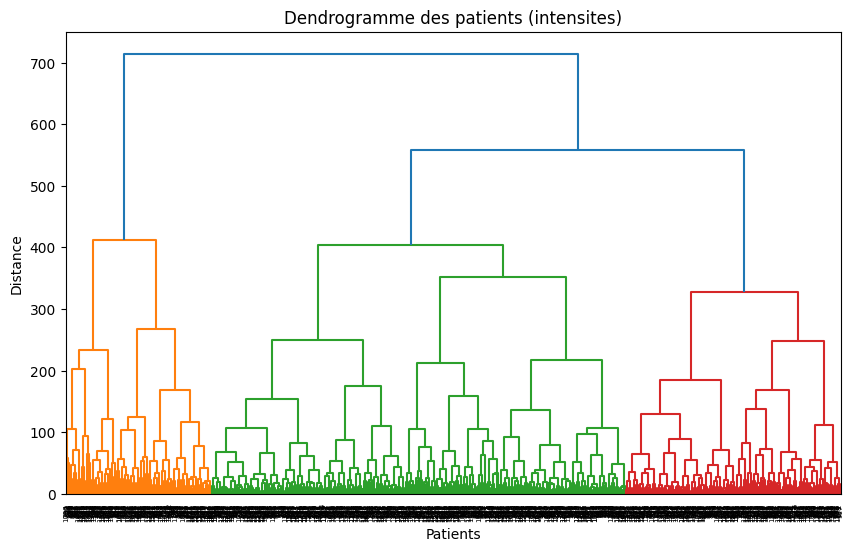

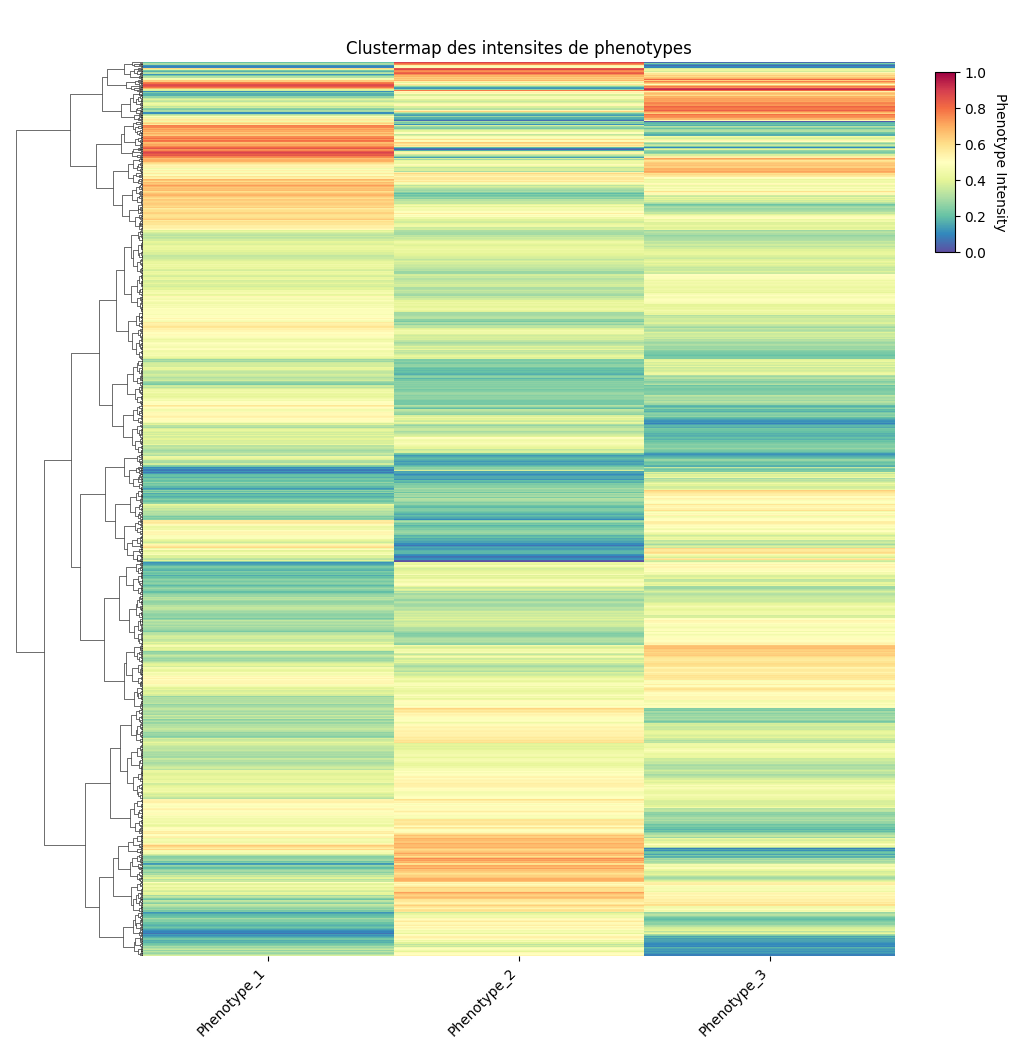

Effectifs par cluster:
1     88
2    163
3    715
4    370
Name: count, dtype: int64


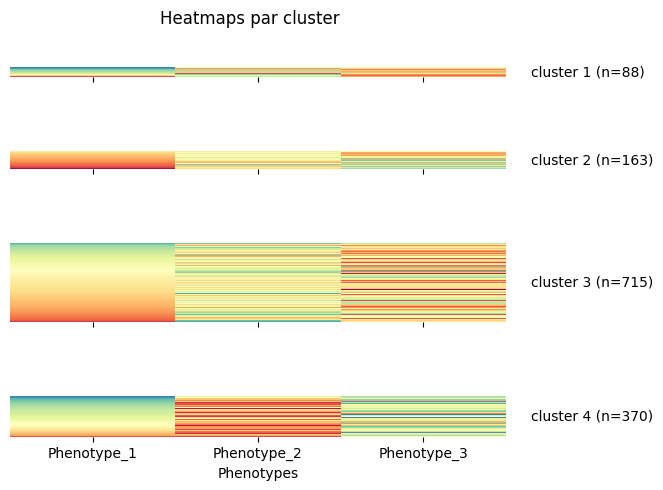

In [15]:
distance_matrix = tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = tca.hierarchical_clustering(distance_matrix)

# Visualisations standard du package
tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)')
tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

clusters = tca.assign_clusters(linkage_matrix, num_clusters=4)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')